In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [10]:
df = pd.read_csv("../Data/Salary_dataset.csv")

In [11]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [16]:
df = df.drop(columns=['Unnamed: 0'])

In [17]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


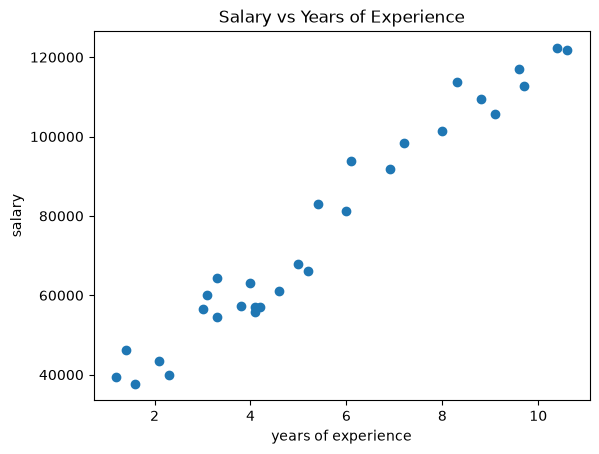

In [18]:
## scatter plot of the data
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('years of experience')
plt.ylabel('salary')
plt.title('Salary vs Years of Experience')
plt.show()

In [19]:
## finding correlation between the two variables
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


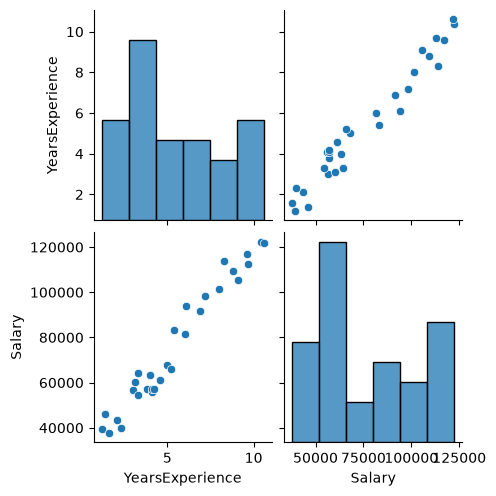

In [20]:
## seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [21]:
## independent and dependent features
X = df[['YearsExperience']] # independent feature should be 2D array
Y = df['Salary'] # dependent feature can be 1D array


In [22]:
np.array(X).shape

(30, 1)

In [23]:
np.array(Y).shape

(30,)

In [25]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(24, 1)
(6, 1)
(24,)
(6,)


## Standerdization of the data

Z-score = xi - mean of x / standerd deviation


In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# when we user fit_transform on training data only while transform only we use on test data. This is because we want to use the same scaling parameters that we used for training data on test data. we don't want to fit the scaler again on test data because that would give us different scaling parameters.

In [31]:
## applying linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [32]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[27151.54]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.421e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.9]


In [35]:
print("coefficient or slop:", model.coef_)

coefficient or slop: [27151.53742583]


In [36]:
print("Intercept:",model.intercept_)

Intercept: 74208.625


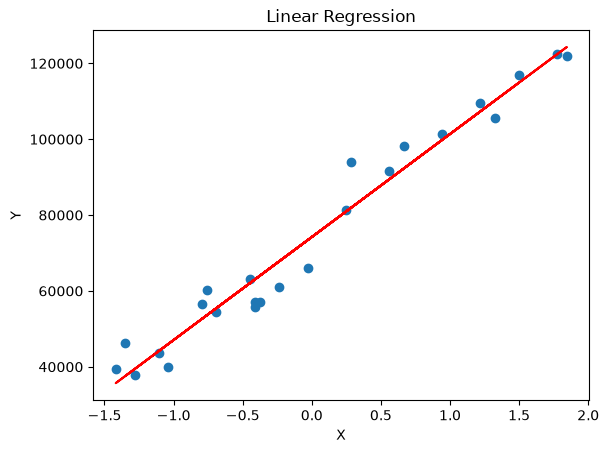

In [37]:
## plot training data plot best fit line

plt.scatter(X_train, Y_train)
plt.plot(X_train, model.predict(X_train), color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.show()

In [38]:
## prediction for test data
Y_pred = model.predict(X_test)

In [39]:
## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [40]:
MSE = mean_squared_error(Y_test, Y_pred)
MAE = mean_absolute_error(Y_test,Y_pred)
RMSE = np.sqrt(MSE)
print(MSE)
print(MAE)
print(RMSE)

49830096.85590836
6286.453830757742
7059.043621901507


In [41]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test,Y_pred)
print(r2)

0.9024461774180498


In [42]:
from sklearn.metrics import adjusted_rand_score
adjusted_r2 = adjusted_rand_score(Y_test,Y_pred)
print(adjusted_r2)

1.0


c:\My_Learning\ML_Learning\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


In [46]:
## OLS linear regression
import statsmodels.api as sm

In [47]:
model_ols = sm.OLS(Y_train,X_train).fit()

In [48]:
prediction_ols = model_ols.predict(X_test)
print(prediction_ols)

[ 41582.58511287  -2709.34690537  28389.24366063   1060.17922384
 -18729.83295452 -14017.92529301]


In [49]:
print(model_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.118
Model:                            OLS   Adj. R-squared (uncentered):              0.079
Method:                 Least Squares   F-statistic:                              3.064
Date:                Tue, 01 Sep 2026   Prob (F-statistic):                      0.0934
Time:                        22:42:53   Log-Likelihood:                         -303.26
No. Observations:                  24   AIC:                                      608.5
Df Residuals:                      23   BIC:                                      609.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [45]:
## prediction for new data
model.predict(scaler.transform([[5]]))

c:\My_Learning\ML_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([71499.27809463])